# Vérification des moindres carrés non linéaires du modèle de Chaboche

## Introduction

L'objectif de ce document est de vérifier la distribution des paramètres du problème de moindres carrés non linéaires. Plus précisément, on vérifie que les méthodes `getObservationsError` et `getParameterPosterior` de la classe `NonLinearLeastSquaresCalibration` sont correctes. 

On considère le modèle de Chaboche, présenté dans la documentation d'OpenTURNS :

http://openturns.github.io/openturns/master/usecases/use_case_chaboche.html

Le modèle de Chaboche est proche d'un modèle linéaire, sans être toutefois exactement linéaire.

La méthode de vérification est présentée dans "Vérification des moindres carrés linéaires". 

## Définit le modèle

In [1]:
import pylab as pl
import openturns as ot
import openturns.viewer as otv
import numpy as np
import otcalibration as otc
import matplotlib

matplotlib.rcParams["font.size"] = "12"

In [2]:
ot.RandomGenerator.SetSeed(0)

def modelChaboche(X):
    strain, R, C, gamma = X
    stress = R + C * (1.0 - np.exp(-gamma * strain)) / gamma
    return [stress]

g = ot.PythonFunction(4, 1, modelChaboche)
g.setInputDescription(["Strain", "R", "C", "Gamma"])

trueR = 750.0
trueC = 2750.0
trueGamma = 10.0
trueParameter = ot.Point([trueR, trueC, trueGamma])

parameterDimension = trueParameter.getDimension()
print("parameterDimension = ", parameterDimension)

calibratedIndices = [1, 2, 3]
model = ot.ParametricFunction(g, calibratedIndices, trueParameter)

parameterDimension =  3


On définit la distribution des erreurs d'observation. 

In [3]:
stressObservationNoiseSigma = 10.0  # (Pa)
observationOutputNoise = ot.Normal(0.0, stressObservationNoiseSigma)

referenceR = 700  # Exact : 750
referenceC = 2500  # Exact : 2750
referenceGamma = 8.0  # Exact : 10
candidate = ot.Point([referenceR, referenceC, referenceGamma])
descr = ["R", "C", "Gamma"]
print("candidate = ", candidate)

candidate =  [700,2500,8]


## Calage

La fonction suivant génère un échantillon d'observations et de réaliser le calage par moindres carrés non linéaires.

In [4]:
def calibrate_model(size, model, trueParameter, observationOutputNoise, candidate):
    """
    Génère un échantillon d'observations et réalise le calage.
    """
    data = np.linspace(0.0, 0.07, size)
    inputObservations = ot.Sample([[v] for v in data])
    # 1. Generate exact (deterministic) outputs
    model.setParameter(trueParameter)    
    outputStress = model(inputObservations)
    # 2. Add noise
    sampleNoiseH = observationOutputNoise.getSample(size)
    outputObservations = outputStress + sampleNoiseH
    # 3. Calibrate
    model.setParameter(candidate)
    algo = ot.NonLinearLeastSquaresCalibration(
        model, inputObservations, outputObservations, candidate, 
    )
    algo.run()
    calibrationResult = algo.getResult()
    return calibrationResult, inputObservations

size = 100
calibrationResult, inputObservations = calibrate_model(
    size, model, trueParameter, observationOutputNoise, candidate
)

La méthode `getParameterMAP` retourne le maximum _a posteriori_ du paramètre $\theta$.

In [5]:
thetaStar = calibrationResult.getParameterMAP()
print("thetaStar = ", thetaStar)

thetaStar =  [747.574,2949.58,11.4999]


## Vérifie la distribution des résidus

Dans cette section, nous vérifions la distribution des résidus $\epsilon$.

residualDistribution =  Normal(mu = 0.00169075, sigma = 9.85339)


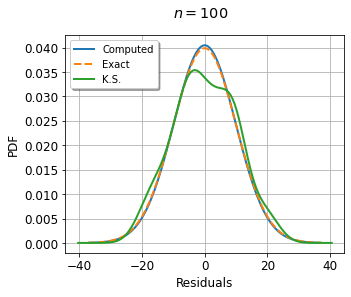

In [6]:
residualDistribution = calibrationResult.getObservationsError()
residualDistribution.setDescription(["Residuals"])
print("residualDistribution = ", residualDistribution)

residualFunction = calibrationResult.getResidualFunction()
meanPosterior = calibrationResult.getParameterPosterior().getMean()
posteriorResiduals = residualFunction(meanPosterior)
residualsSample = ot.Sample([[v] for v in posteriorResiduals])

kernel = ot.KernelSmoothing()
fittedDist = kernel.build(residualsSample)
residualPDF = fittedDist.drawPDF()
residualPDF.setLegends(["K.S."])

graph = residualDistribution.drawPDF()
graph.setLegends(["Computed"])
graphExact = observationOutputNoise.drawPDF().getDrawable(0)
graphExact.setLegend("Exact")
graphExact.setLineStyle("dashed")
graph.add(graphExact)
graph.add(residualPDF)
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
graph.setTitle("$n=%d$" % (size))
view = otv.View(graph, figure_kw={"figsize": (5.0, 4.0)})

On observe que la distribution estimée des résidus est proche de la distribution exacte. 

## Distribution du résidu en fonction de la taille de l'échantillon

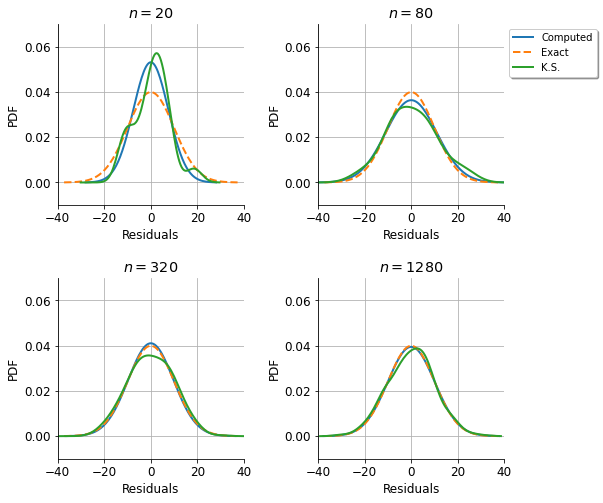

In [7]:
def simulate_and_plot_residuals(size):
    """
    Dessine la distribution des résidus.
    
    Parameters
    ----------
    size : int
        La taille de l'échantillon
    
    Returns
    -------
    graph : ot.Graph
        Le graphique
    """
    calibrationResult, inputObservations = calibrate_model(
        size, model, trueParameter, observationOutputNoise, candidate
    )

    # Analysis of the results
    thetaPosterior = calibrationResult.getParameterPosterior()

    # Draw residual distribution
    residualDistribution = calibrationResult.getObservationsError()

    residualFunction = calibrationResult.getResidualFunction()
    meanPosterior = calibrationResult.getParameterPosterior().getMean()
    posteriorResiduals = residualFunction(meanPosterior)
    residualsSample = ot.Sample([[v] for v in posteriorResiduals])

    kernel = ot.KernelSmoothing()
    fittedDist = kernel.build(residualsSample)
    residualPDF = fittedDist.drawPDF()
    residualPDF.setLegends(["K.S."])

    graph = residualDistribution.drawPDF()
    graph.setLegends(["Computed"])
    graphExact = observationOutputNoise.drawPDF().getDrawable(0)
    graphExact.setLegend("Exact")
    graphExact.setLineStyle("dashed")
    graph.add(graphExact)
    graph.add(residualPDF)
    graph.setLegendPosition("topleft")
    graph.setColors(ot.Drawable_BuildDefaultPalette(3))
    graph.setTitle("$n=%d$" % (size))
    graph.setXTitle("Residuals")
    bounding_box = ot.Interval([-40.0, -0.01], [40.0, 0.07])
    graph.setBoundingBox(bounding_box)
    return graph

grid = ot.GridLayout(2, 2)
graph = simulate_and_plot_residuals(20)
graph.setLegends([""])
grid.setGraph(0, 0, graph)
graph = simulate_and_plot_residuals(80)
grid.setGraph(0, 1, graph)
graph = simulate_and_plot_residuals(320)
graph.setLegends([""])
grid.setGraph(1, 0, graph)
graph = simulate_and_plot_residuals(1280)
graph.setLegends([""])
grid.setGraph(1, 1, graph)
view = otv.View(
    grid,
    figure_kw={"figsize": (8.0, 8.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)
pl.subplots_adjust(wspace=0.4, hspace=0.4)

On observe que la distribution des empirique des résidus ("K.S.") est de plus en plus proche de la vraie distribution lorsque la taille de l'échantillon augmente.

(-0.01, 0.05)

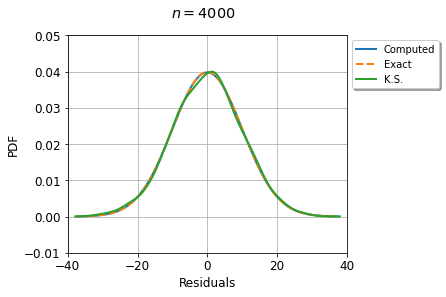

In [8]:
graph = simulate_and_plot_residuals(4000)
view = otv.View(
    graph,
    figure_kw={"figsize": (5.0, 4.0)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)
pl.ylim(top = 0.05)

Lorsque la taille de l'échantillon est très grande, on ne peut pas distinguer la distribution du résidu estimée et la vraie distribution.

## Vérifie la distribution des paramètres

Dans cette section, nous vérifions la distribution des paramètres, c'est à dire la valeur de retour de la méthode `getParameterPosterior`. 

In [9]:
thetaPosterior = calibrationResult.getParameterPosterior()

Dans la boucle suivante, nous générons un échantillon du vecteur des paramètres $\theta$. Pour cela, nous répétons 20 calage indépendants et nous stockons le vecteur des paramètres dans l'échantillon `sampleTheta`. 

In [10]:
randomVector = otc.NonLinearLeastSquaresCalibrationRandomVector(
    model, trueParameter, inputObservations, observationOutputNoise, candidate
)
randomVector = ot.RandomVector(randomVector)
resampleSize = 20
sampleTheta = randomVector.getSample(resampleSize)
sampleTheta[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=3 description=[x0,x1,x2] data=[[757.374,2364.34,7.87406],[746.76,2867.71,10.4655],[752.356,2645.24,8.36593],[752.363,2508.34,7.68299],[748.144,2842.4,10.9468]]

Nous dessinons la distribution obtenue avec un calage et nous comparons avec la distribution empirique du paramètre $\theta$. Pour cela, nous approchons la distribution des paramètres par une méthode de lissage à noyau en utilisant la classe `KernelSmoothing`. 

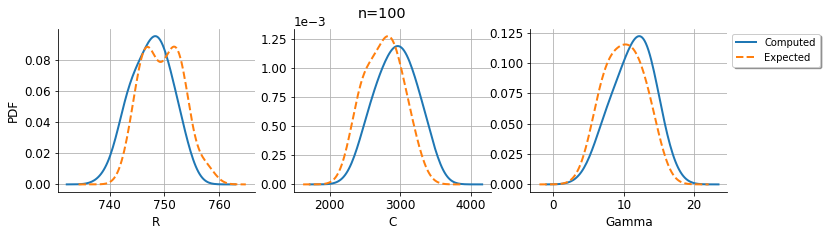

In [11]:
grid = ot.GridLayout(1, parameterDimension)
for i in range(parameterDimension):
    thetai = thetaPosterior.getMarginal(i)
    graph = thetai.drawPDF()
    graph.setLegends(["Computed"])
    graph.setXTitle(descr[i])
    # From data
    sampleMargin = sampleTheta.getMarginal(i)
    ksdist = ot.KernelSmoothing().build(sampleMargin).drawPDF().getDrawable(0)
    ksdist.setLegend("Expected")
    ksdist.setLineStyle("dashed")
    graph.add(ksdist)
    graph.setColors(ot.Drawable_BuildDefaultPalette(2))
    if i > 0:
        graph.setYTitle("")
    if i != parameterDimension - 1:
        graph.setLegends([""])
    grid.setGraph(0, i, graph)
grid.setTitle("n=%d" % (size))
view = otv.View(
    grid,
    figure_kw={"figsize": (12, 3)},
    legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
)

On observe que la distribution estimée est proche de la distribution empirique attendue. 

## Lorsque la taille de l'échantillon augmente

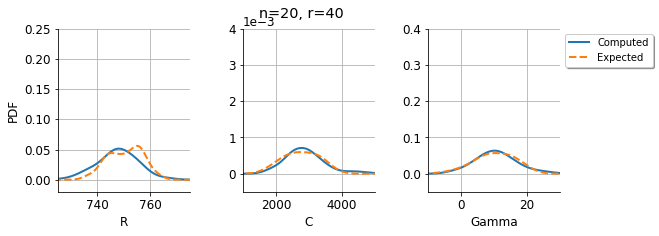

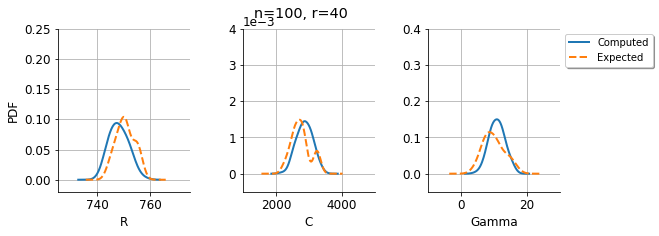

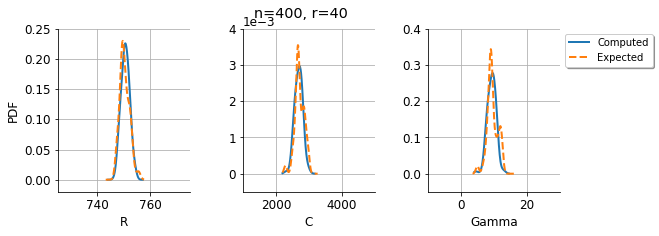

In [12]:
def simulate_and_plot_parameter(size, resampleSize = 20):
    # Single calibration
    calibrationResult, inputObservations = calibrate_model(
        size, model, trueParameter, observationOutputNoise, candidate
    )
    thetaPosterior = calibrationResult.getParameterPosterior()
    randomVector = otc.NonLinearLeastSquaresCalibrationRandomVector(
        model, trueParameter, inputObservations, observationOutputNoise, candidate
    )
    randomVector = ot.RandomVector(randomVector)
    sampleTheta = randomVector.getSample(resampleSize)
    # Dessin
    grid = ot.GridLayout(1, parameterDimension)
    list_of_bounding_boxes = [
        ot.Interval([725.0, -0.02], [775.0, 0.25]),
        ot.Interval([1000.0, -0.5e-3], [5000.0, 4.e-3]),
        ot.Interval([-10.0, -0.05], [30.0, 0.4]),
    ]
    for i in range(parameterDimension):
        thetai = thetaPosterior.getMarginal(i)
        graph = thetai.drawPDF()
        graph.setLegends(["Computed"])
        graph.setXTitle(descr[i])
        # From data
        sampleMargin = sampleTheta.getMarginal(i)
        ksdist = ot.KernelSmoothing().build(sampleMargin).drawPDF().getDrawable(0)
        ksdist.setLegend("Expected")
        ksdist.setLineStyle("dashed")
        graph.add(ksdist)
        graph.setColors(ot.Drawable_BuildDefaultPalette(2))
        if i > 0:
            graph.setYTitle("")
        if i != parameterDimension - 1:
            graph.setLegends([""])
        graph.setBoundingBox(list_of_bounding_boxes[i])
        grid.setGraph(0, i, graph)
    grid.setTitle("n=%d, r=%d" % (size, resampleSize))
    view = otv.View(
        grid,
        figure_kw={"figsize": (9.0, 3.0)},
        legend_kw={"bbox_to_anchor": (1.0, 1.0), "loc": "upper left"},
    )
    pl.subplots_adjust(wspace=0.4, hspace=0.4)
    return view

view = simulate_and_plot_parameter(20, resampleSize = 40)

view = simulate_and_plot_parameter(100, resampleSize = 40)

view = simulate_and_plot_parameter(400, resampleSize = 40)

On observe que la distribution calculée n'est jamais très éloignée de la distribution attendue. Toutefois, le rapprochement n'est pas si évident. La raison est peut-être le petit nombre de répétitions. Le problème est que la simulation est relativement longue et augmenter le nombre de répétitions nécessite plus de temps. 